# Chapter 08 이미지를 위한 인공 신경망
## 08-3 합성곱 신경망의 시각화
### 가중치 시각화
* 합성곱 층은 여러 개의 필터를 사용해 이미지에서 특징을 학습. 각 필터는 커널이라 부르는 가중치와 절편을 가지고 있음. 일반적으로 절편은 시각적으로 의미가 있지 않음. 가중치는 입력 이미지의 2차원 영역에 적용되어 어떤 특징을 크게 두드러지게 표현하는 역할.
* 이 필터의 가운데 곡선 부분의 가중치 값은 높고 그 외 부분의 가중치 값은 낮을 것. 이렇게 해야 둥근 모서리가 있는 입력과 곱해져서 큰 출력을 만들기 때문.

In [ ]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))

In [ ]:
model.add(keras.layers.MaxPooling2D(2))

In [ ]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [ ]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7388 - loss: 0.7286

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.8073 - loss: 0.5382 - val_accuracy: 0.8784 - val_loss: 0.3325
Epoch 2/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8675 - loss: 0.3735

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8721 - loss: 0.3592 - val_accuracy: 0.8867 - val_loss: 0.3062
Epoch 3/20
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8843 - loss: 0.3151

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8882 - loss: 0.3094 - val_accuracy: 0.8978 - val_loss: 0.2744
Epoch 4/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8990 - loss: 0.2836

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8979 - loss: 0.2820 - val_accuracy: 0.9113 - val_loss: 0.2454
Epoch 5/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9080 - loss: 0.2559

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9078 - loss: 0.2543 - val_accuracy: 0.9122 - val_loss: 0.2410
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9157 - loss: 0.2334

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9150 - loss: 0.2341 - val_accuracy: 0.9165 - val_loss: 0.2249
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9213 - loss: 0.2164 - val_accuracy: 0.9171 - val_loss: 0.2258
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9259 - loss: 0.1999 - val_accuracy: 0.9141 - val_loss: 0.2366


In [ ]:
from tensorflow import keras
model = keras.models.load_model('best-cnn-model.h5')

In [ ]:
model.layers

[<Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [ ]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [12]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.0331186 0.25241315


* 이 가중치의 평균값은 0에 가깝고 표준편차는 0.27 정도

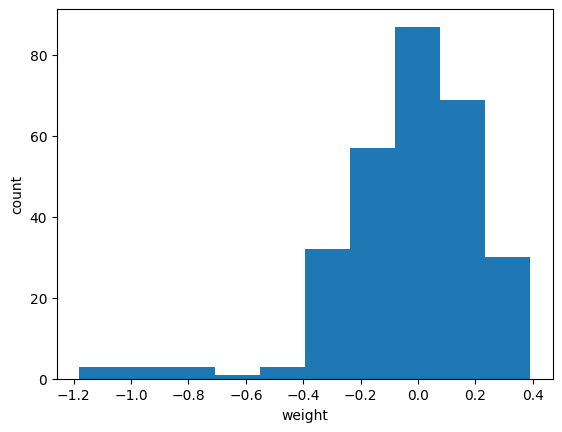

In [13]:
import matplotlib.pyplot as plt
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

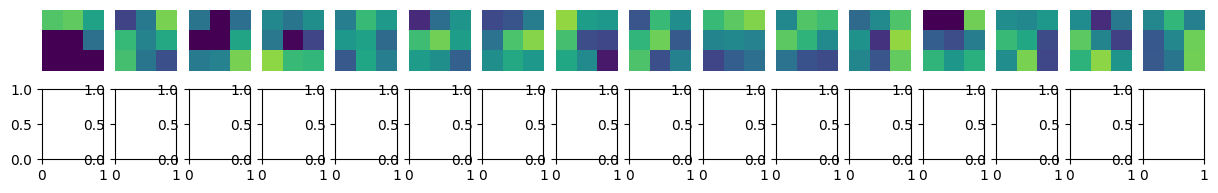

In [14]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
  for j in range(16):
    axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
  plt.show()

* 결과 그래프를 보면 이 가중치 값이 무작위로 나열된 것이 아닌 어떤 패턴을 볼 수 있음. 예를 들어 첫 번째 줄의 맨 왼쪽 가중치는 오른쪽 3픽셀의 값이 높음(밝은 부분의 값이 높음). 이 가중치는 오른쪽에 놓인 직선을 만나면 크게 활성화될 것.

In [15]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [17]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

-0.00010527318 0.082056075


* 평균은 이전과 동일하게 0에 가깝지만 표준편차는 이전과 달리 매우 작음.

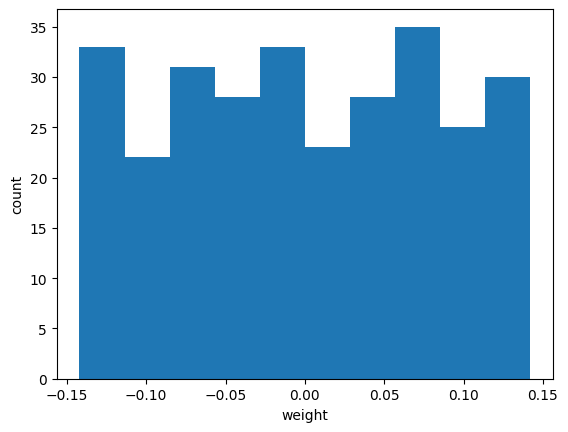

In [18]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

* 이 그래프는 이전과 확실히 다름. 대부분의 가중치가 -0.15~0.15 사이에 있고 비교적 고른 분포를 보임. 이런 이유는 텐서플로가 신경망의 가중치를 처음 초기화할 때 균등 분포에서 랜덤하게 값을 선택하기 때문.

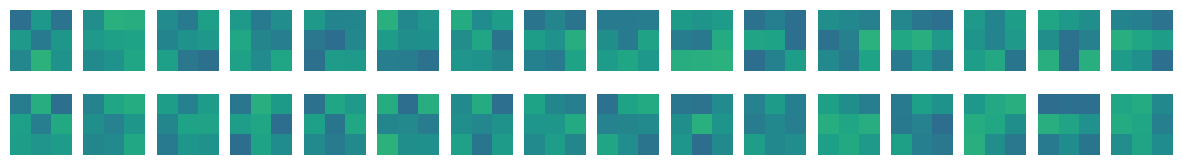

In [20]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
  for j in range(16):
    axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 함수형 API
* 지금까지는 신경망 모델을 만들 때 케라스 Sequential 클래스를 사용했음. 이 클래스는 층을 차례대로 쌓은 모델을 만듦. 딥러닝에서는 좀 더 복잡한 모델이 많이 있음. 예를 들어 입력이 2개일 수도 있고 출력이 2개일 수도 있음. 이런 경우는 Sequential 클래스를 사용하기 어려움. 대신 **함수형 APIfunctional API**를 사용.


```
dense1 = keras.layers.Dense(100, activation='sigmoid')
dense2 = keras.layers.Dense(10, activation='softmax')
```

* 앞의 코드는 7장에서 보았던 것과 거의 동일. 이 객체를 Sequential 클래스 객체의 `add()` 메서드에 전달할 수 있음. 하지만 다음과 같이 함수처럼 호출할 수도 있음.

```
hidden = dense1(inputs)
```


* 사실 파이썬의 모든 객체는 호출 가능. 케라스의 층은 객체를 함수처럼 호출했을 때 적절히 동작할 수 있도록 미리 준비해 놓았음. 앞의 코드를 실행하면 영리하게도 입력값 inputs를 Dense층에 통과시킨 후 출력값 hidden을 만들어 줌.
* 그다음 두 번째 층을 호출.

```
outputs = dense2(hidden)
```

* 그다음 inputs와 outputs을 Model 클래스로 연결해 주면 됨.



```
model = keras.Model(inputs, outputs)
```

* 입력에서 출력까지 층을 호출한 결과를 계속 이어주고 Model 클래스에 입력과 최종 출력을 지정. 그런데 inputs는 어디서 온 걸까요? 이전 절에서 plot_model() 함수로 모델의 층을 도식화했을 때 InputLayer 클래스가 맨 처음 나왔던 것을 기억하나요? Sequential 클래스는 InputLayer 클래스를 자동으로 추가하고 호출해 주지만 Model 클래스에서는 우리가 수동으로 만들어서 호출해야 함. 바로 inputs가 InputLayer 클래스의 출력값이 되어야 함!

> Sequential 클래스에서 InputLayer의 객체는 어디에 저장되어 있나요?
> * 케라스 모델은 layers 속성 외에 InputLayer 객체를 포함한 _self_tracked_trackables 리스트 속성을 따로 가지고 있음. Sequential 클래스 객체의 _self_tracked_trackables 속성의 첫 번째 항목이 바로 InputLayer 클래스의 객체. InputLayer 클래스는 신경망의 입력층 역할. 즉 모델의 입력을 첫 번째 은닉층에 전달하는 역할을 수행. 따라서 InputLayer 객체의 입력과 출력은 동일.

* 다행히 케라스는 InputLayer 클래스 객체를 쉽게 다룰 수 있도록 Input() 함수를 별도로 제공. 입력의 크기를 지정하는 shape 매개변수와 함께 이 함수를 호출하면 InputLayer 클래스 객체를 만들어 출력을 반환해 줌.



```
inputs = keras.Input(shape=(784,))
```

* 마치 체인처럼 입력에서 출력까지 연결하고 마지막에 Model 클래스에 입력과 출력을 지정하여 모델을 만듦. 이렇게 모델을 만들게 되면 중간에 다양한 형태로 층을 연결할 수 있음. 그런데 특성 맵 시각화를 만드는 데 함수형 API가 왜 필요한 것일까요? 2절에서 정의한 model 객체의 층을 순서대로 나열하면 다음과 같음.
  * model 객체 -> InputLayer -> Conv2D -> Maxpooling2D -> Conv2D -> Maxpooling2D -> Flatten -> Dense -> Dropout -> Dense
* 우리가 필요한 것은 첫 번째 Conv2D의 출력. model 객체의 입력과 Conv2D의 출력을 알 수 있다면 이 둘을 연결하여 새로운 모델을 얻을 수 있지 않을까?
* model 객체의 `predict()` 메서드를 호출하면 입력부터 마지막 층까지 모든 계산을 수행한 후 최종 출력을 반환. 하지만 우리가 필요한 것은 첫 번째 Conv2D 층이 출력한 특성 맵. 첫 번째 층의 출력은 Conv2D 객체의 output 속성에서 얻을 수 있음. model.layers[0].output처럼 참조할 수 있음. model 객체의 입력은 어떻게 얻을 수 있을까? 다행히 케라스 모델의 입력은 inputs 속성으로 참조할 수 있으며, 첫 번째 입력은 model.inputs[0]으로 얻을 수 있음.


In [30]:
print(model.inputs[0])

<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_1>


In [32]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

### 특성 맵 시각화

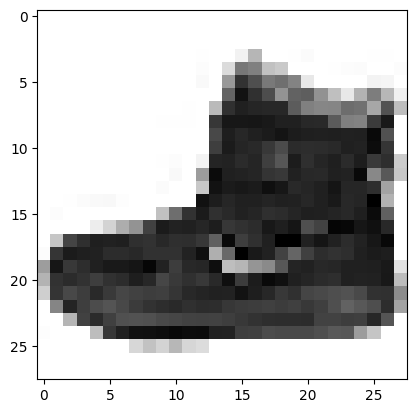

In [33]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [34]:
inputs = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


In [35]:
print(feature_maps.shape)

(1, 28, 28, 32)


* 세임 패딩과 32개의 필터를 사용한 합성곱 층의 출력이므로 (28, 28, 32).

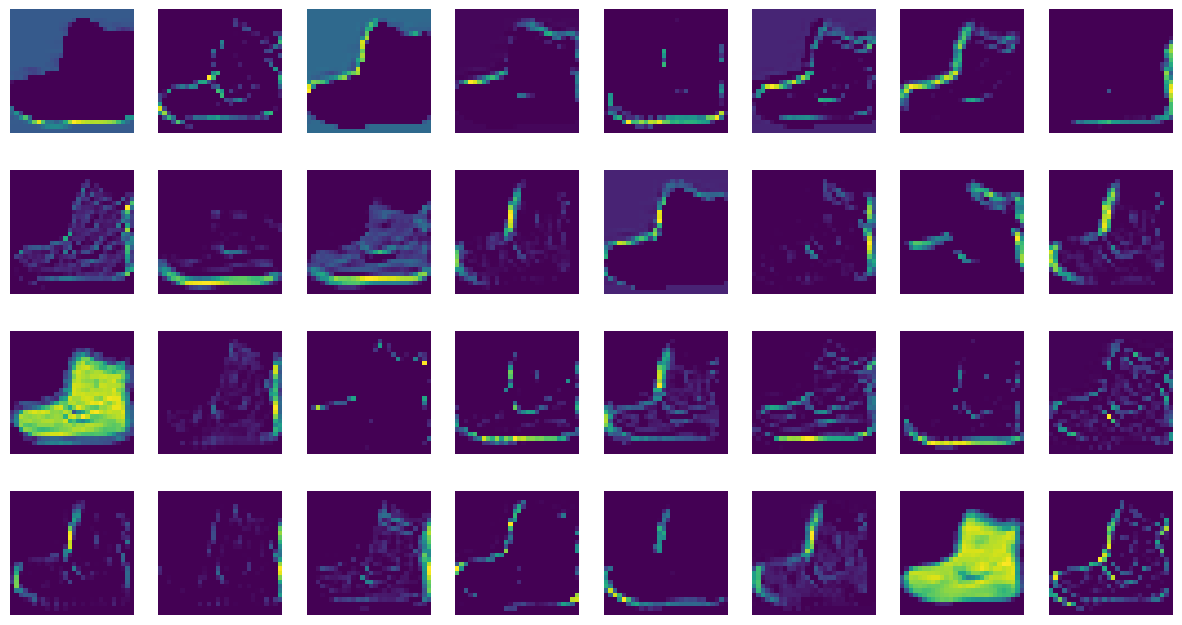

In [36]:
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
    axs[i, j].axis('off')
plt.show()

* 이 특성 맵은 32개의 필터로 인해 입력 이미지에서 강하게 활성화된 부분을 보여 줌.

In [38]:
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)

In [39]:
inputs = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv2_acti.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


* 첫 번째 풀링 층에서 가로세로 크기가 절반으로 줄었고, 두 번째 합성곱 층의 필터 개수는 64개이므로 feature_maps의 크기는 배치 차원을 제외하면 (14, 14, 64)일 것.

In [40]:
print(feature_maps.shape)

(1, 14, 14, 64)


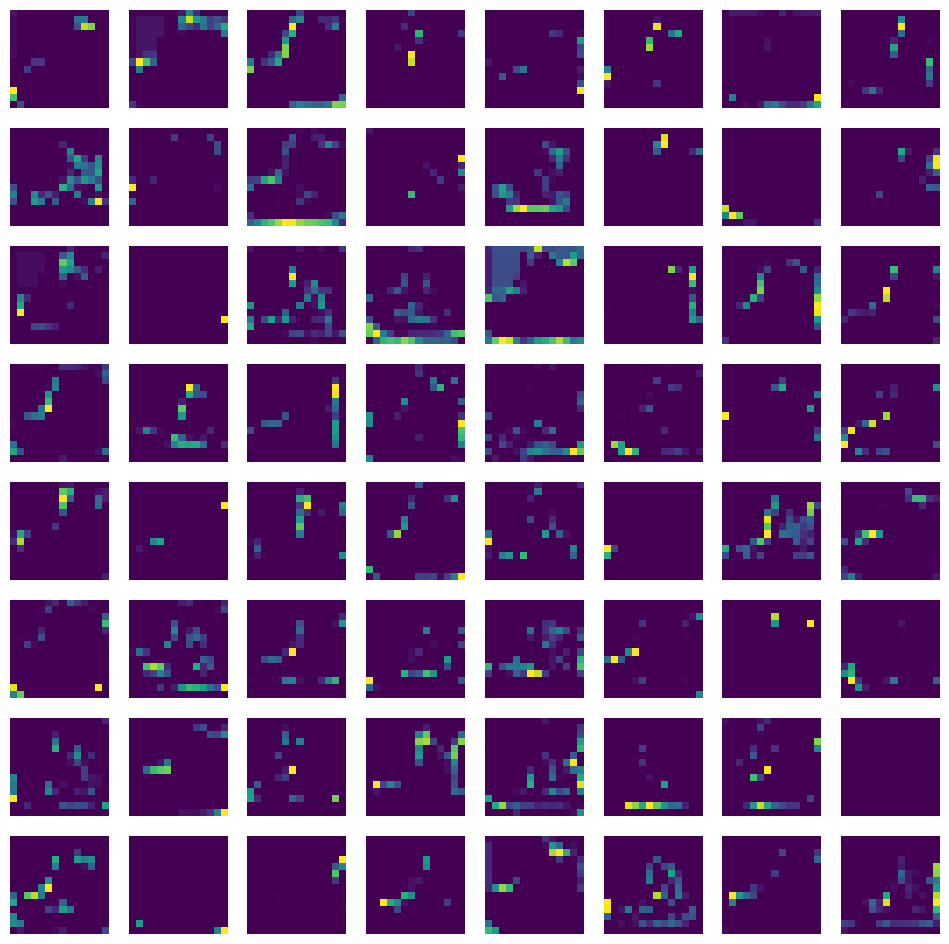

In [41]:
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
  for j in range(8):
    axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
    axs[i, j].axis('off')
plt.show()

* 이 특성 맵은 시각적으로 이해하기 어려움. 왜 이런 결과가 나올까?
* 두 번째 합성곱 층의 필터 크기는 (3, 3, 32). 두 번째 합성곱 층의 첫 번째 필터가 앞서 출력한 32개의 특성 맵과 곱해져 두 번째 합성곱 층의 첫 번째 특성 맵이 됨.
* 이런 현상은 합성곱 층을 많이 쌓을수록 심해짐. 이를 바꾸어 생각하면 합성곱 신경망의 압부분에 있는 합성곱 층은 이미지의 시각적인 정보를 감지하고 뒤쪽에 있는 합성곱 층은 앞쪽에서 감지한 시각적인 정보를 바탕으로 추상적인 정보를 학습한다고 볼 수 있음. 합성곱 신경망이 패션 MNIST 이미지를 인식하여 10개의 클래스를 찾아낼 수 있는 이유가 바로 여기에 있음!